
# 1.모델 성능 평가 지표(metrix)
>실제 값과 모델의 의한 예측값을 비교하여 모델의 성능을 측정하는 방법

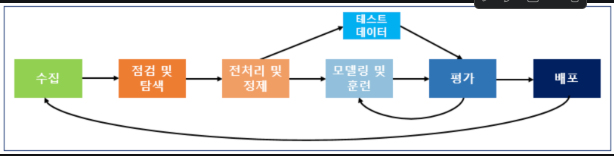

## 1-1.회귀 모형 성능 측정

### 1-1.1.회귀 모델 학습 및 예측

In [ ]:
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression


diabetes = load_diabetes()

data = diabetes.data
target = diabetes.target

SEED = 42
x_train, x_valid , y_train, y_valid = train_test_split(data, target, random_state=SEED)

# 모델 생성
model = LinearRegression()
# 모델 학습
model.fit(x_train,y_train)
# 모델 예측
pred = model.predict(x_valid)


## 1-2.회귀 평가 지표

### 1) R2(결정계수)
>coefficient of Determination -> error즉 오차가 아님. 

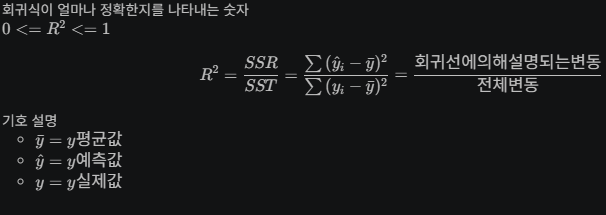

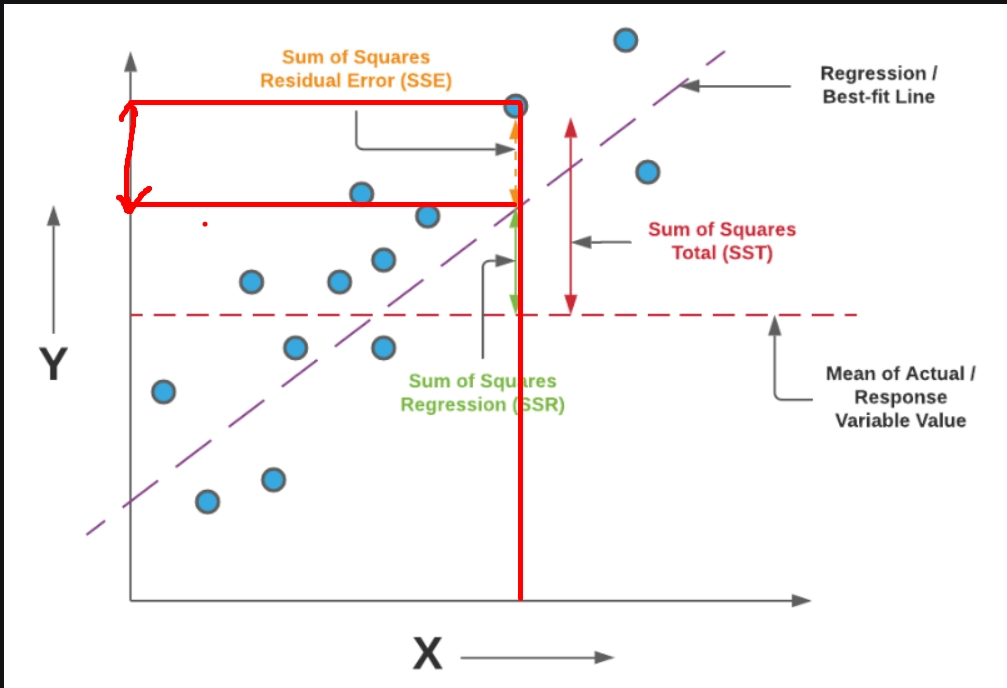

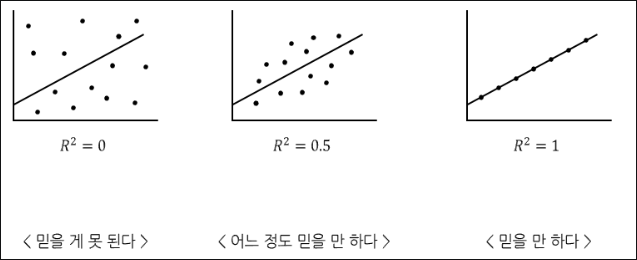

In [5]:
from sklearn.metrics import r2_score

r2 = r2_score(y_valid, pred)
r2

np.float64(0.4849058889476757)

### 2) MSE(Mean Squared Error)

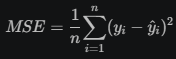
>SSE(실제값 - 예측값)를 제곱한뒤 평균

>장점 - 이상치 민감

>단점 - 직관적이지 못함 & 오차가 제곱되어서 뻥튀기 됨.

### 3) RMSE(Root Mean Squared Error)

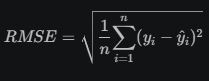
>MSE에 루트 & L2 norm

>MSE에서 오차가 제곱되어 뻥튀기되는걸 방지함.

### 3) RMSE(Root Mean Squared Error)

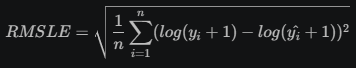
>log를 취한뒤 rmse 한 것

>로그는 x가 커질수록 y 변화량이 점점 작아짐 → 큰 값(이상치)일수록 더 세게 압축됨 → 오른쪽으로 길게 튄 값들이 눌려서 좌우대칭에 가까워짐. 단, 왼쪽으로 쏠렸을 땐 못 씀 (로그는 0 이하에서 정의 안 됨).

>타겟값 자체가 오른쪽으로 치우쳐 있고, "절대 오차"보다 "비율 오차"를 공정하게 보고 싶을 때.사용

>실제 예시 — 집값 예측  
>집 A: 실제 1억, 예측 1억 2천만 → 오차 2천만  
>집 B: 실제 10억, 예측 10억 2천만 → 오차 2천만  
>**RMSE(그냥 로그 안 씌운 오차)로 보면 두 오차가 똑같이 "2천만"**이라 동등하게 취급돼. 근데 집 A 입장에서 2천만 오차는 20% 차이인데, 집 B 입장에서는 겨우 2% 차이야. RMSLE는 이런 "비율 차이"를 더 공정하게 반영해줘 — 절대적인 금액이 아니라 "몇 % 틀렸는가"를 기준으로 오차를 계산하니까.

---

### MSE(L2 norm) vs MAE(L1 norm)
>MSE(제곱): 오차가 크면 클수록 "더 크게" 벌점을 줌  ->이상치에 민감  
MAE(절대값): 오차 크기에 비례해서 "일정하게" 벌점을 줌 ->이상치에 덜 민감

>예시로 확인해보자  
오차가 2일 때: MSE 기여분 = 4,   MAE 기여분 = 2  
오차가 10일 때: MSE 기여분 = 100,  MAE 기여분 = 10  (10배 커졌는데 MSE는 25배 커짐!)

>MSE는 오차가 클수록 "기하급수적으로" 더 크게 벌점을 줘서, 이상치(가끔 나오는 큰 오차) 하나가 전체 지표를 왕창 끌어올려버려.  
>MAE는 오차 크기에 비례해서만 벌점을 주니까, 이상치에 덜 휘둘리고 "평균적으로 얼마나 틀리는지"를 더 안정적으로 보여줘.

### 4) MAE(Mean Absolute Error)
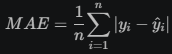


### 5) MAPE(Mean Absolute Percentage Error)
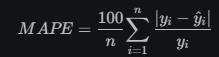

>실제값에 대한 절대오차 비율의 평균을 비율로 표현  

>MSE, RMSE의 단점을 보완(오차를 "절대적인 숫자"로만 표현함)  

>이게 "단점"이라기보다는, "이 숫자만 보고는 좋은지 나쁜지 판단하기 어렵다"는 한계야.  
>예를 들어: RMSE = 50  
>이게 좋은 결과야, 나쁜 결과야? 타겟값이 뭐냐에 따라 완전히 달라져.  
>집값(억 단위)을 예측하는데 RMSE 50 → 엄청 정확한 것  
>온도(섭씨)를 예측하는데 RMSE 50 → 완전히 망한 것

>하지만, 분모인 실제값이 0인경우 망가짐.

### 6) SMAPE(Symmetric Mean Absolute Percentage Error)
> 기존 MAPE의 단점 보완
> MPAE와 다른점은 각 실제값과 예측값을 절대값으로 변경후 합으로 나눈다.
> 그러므로 실제값이 0이 존재해도 계산이 가능하다.

> 특징, 과소추정에 대한 패널티를 줄 수 있다.
숫자로 확인해보면 (검색 결과에서 나온 예시)  
실제값	예측값	MAPE	SMAPE  
100	110 (과대추정)	10%	9.52%  
100	90 (과소추정)	10%	10.53%  

MAPE는 두 경우를 똑같이 "10% 틀렸다"고 평가하는데, SMAPE는 과소추정(90)일 때를 살짝 더 나쁘게(10.53%) 평가해.  
오차 크기가 똑같아도, "부족하게 예측한 것"을 "과하게 예측한 것"보다 더 무겁게 벌점을 주는 거야.  

왜 이렇게 설계됐는지

"모자란 예측"이 "과한 예측"보다 실무에서 더 치명적인 경우가 많아서 이런 비대칭적 특성이 자연스럽게 받아들여지는 경우가 많아. 예를 들어 재고 수요 예측에서, 부족하게 예측하면(과소추정) 품절이 나서 매출 기회를 놓치지만, 넉넉하게 예측하면(과대추정) 재고가 좀 남는 정도로 끝나는 경우가 흔하거든. 그래서 "과소추정을 더 조심해야 하는" 상황에서 SMAPE가 자연스럽게 그런 페널티 구조를 갖게 된 거야.


### 번외) MSE계열과 MAPE계열 각각의 쓰이는 경우가 다름
>즉 "MSE → MAPE → SMAPE"는 하나가 다른 하나를 완전히 대체하는 게 아니라, 각자 다른 상황에서 서로 다른 약점을 보완해가며 여러 도구가 병렬로 존재하는 관계야.  
> 실무에서는 상황에 맞게 여러 지표를 같이 보는 경우가 많아 (RMSE로 절대 오차도 확인하고, MAPE로 상대 오차도 같이 확인하는 식으로).